In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.dummy import DummyClassifier

In [2]:
#Load Dataset

X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    weights=[0.9, 0.1],   # Imbalanced dataset
    random_state=42
)

print("Class Distribution:")
print(pd.Series(y).value_counts())

Class Distribution:
0    894
1    106
Name: count, dtype: int64


In [3]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
# Train Classification Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
# Make predictions
y_pred = model.predict(X_test)

In [6]:
# Create basic confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[177   2]
 [ 11  10]]


In [7]:
# Extract TN, FP, FN, TP

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print(f"True Positives  (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Negatives  (TN): {tn}")

True Positives  (TP): 10
False Positives (FP): 2
False Negatives (FN): 11
True Negatives  (TN): 177


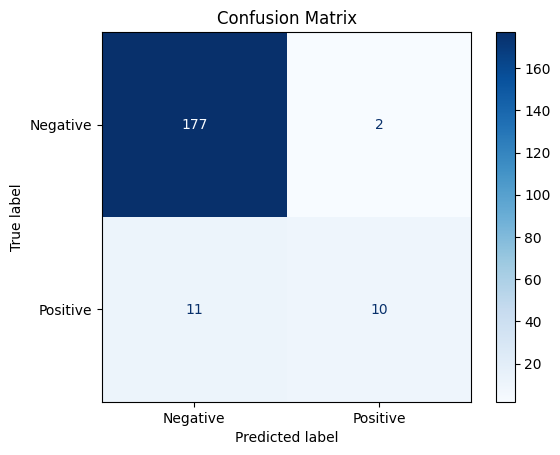

In [8]:
# Visualize Confusion Matrix

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Negative", "Positive"],
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

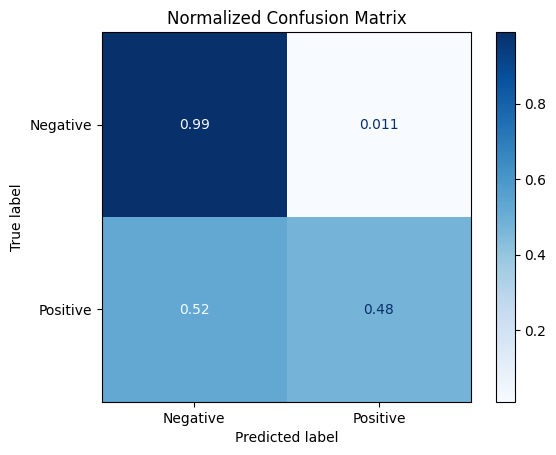

In [9]:
# Normalized Confusion Matrix

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Negative", "Positive"],
    normalize="true",
    cmap="Blues"
)

plt.title("Normalized Confusion Matrix")
plt.show()

In [10]:
# Compute metrics from confusion matrix

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")

Accuracy : 0.935
Precision: 0.833
Recall   : 0.476
F1-Score : 0.606


In [11]:
# Full Classification Report

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.941     0.989     0.965       179
           1      0.833     0.476     0.606        21

    accuracy                          0.935       200
   macro avg      0.887     0.733     0.785       200
weighted avg      0.930     0.935     0.927       200



In [12]:
# Threshold tuning using confusion matrix

y_prob = model.predict_proba(X_test)[:, 1]

thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:
    
    y_custom = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_custom).ravel()
    
    print(f"\nThreshold = {threshold}")
    print(f"TP: {tp} | FP: {fp} | FN: {fn} | TN: {tn}")


Threshold = 0.3
TP: 13 | FP: 13 | FN: 8 | TN: 166

Threshold = 0.5
TP: 10 | FP: 2 | FN: 11 | TN: 177

Threshold = 0.7
TP: 5 | FP: 0 | FN: 16 | TN: 179


Baseline Confusion Matrix:
[[179   0]
 [ 21   0]]


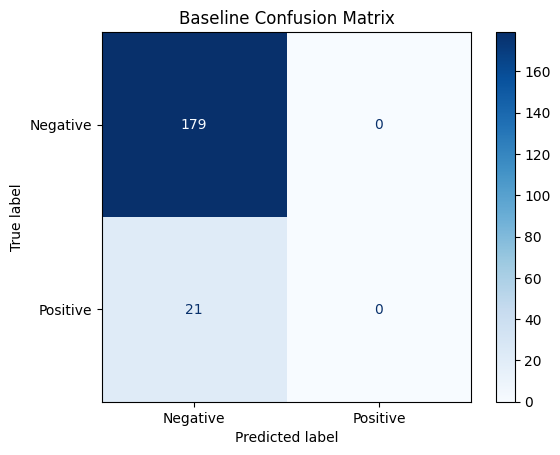

In [13]:
# Baseline Comparison

# Majority class baseline
baseline = DummyClassifier(strategy="most_frequent")

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)


# Baseline Confusion Matrix

baseline_cm = confusion_matrix(y_test, baseline_pred)

print("Baseline Confusion Matrix:")
print(baseline_cm)


#Visualize Baseline Confusion Matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")

plt.title("Baseline Confusion Matrix")
plt.show()

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


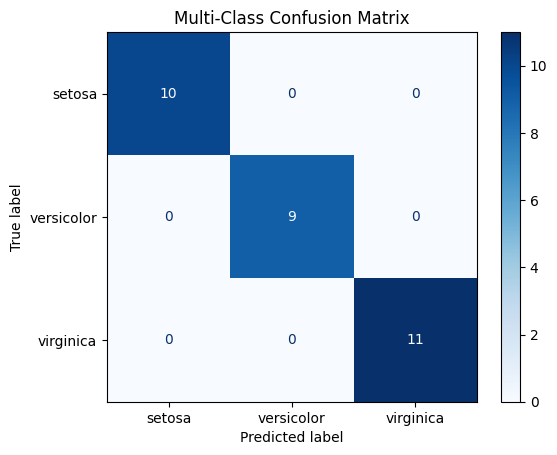

In [14]:
# Multi Class Confusion Matrix

#Multi-class example
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# Multi class matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)


#Visualize multi-class confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title("Multi-Class Confusion Matrix")
plt.show()

In [15]:
# Important Observations

print("Key Observations:")
print("- Confusion Matrix shows exact prediction behavior.")
print("- Accuracy alone can hide minority-class failures.")
print("- FP and FN have different business costs.")
print("- Threshold tuning changes FP/FN trade-off.")
print("- Always inspect normalized confusion matrix on imbalanced data.")

Key Observations:
- Confusion Matrix shows exact prediction behavior.
- Accuracy alone can hide minority-class failures.
- FP and FN have different business costs.
- Threshold tuning changes FP/FN trade-off.
- Always inspect normalized confusion matrix on imbalanced data.
